<a href="https://colab.research.google.com/github/JP-cpu-tech/gravlensing-nn/blob/main/GL_model_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── CELL 1: Install & Imports ────────────────────────────────
# !pip install -q torchvision timm scikit-learn matplotlib seaborn

import os, random, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageDraw, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import timm  # for EfficientNet / ViT backbones

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# ── CELL 2: Class Definitions ────────────────────────────────
# The network performs a TWO-STAGE classification:
#
#   Stage 1 — Binary:  Lensed  vs  Non-lensed
#   Stage 2 — Multi:   Strong  |  Weak  |  Microlensing
#
# Lensing types explained
# ────────────────────────
# STRONG LENSING   — Galaxy/cluster bends light into arcs, rings (Einstein rings),
#                    or multiple images. Visually dramatic distortions.
# WEAK LENSING     — Statistical shape distortion of background galaxies; subtle,
#                    requires ensemble statistxics to detect.
# MICROLENSING     — Point-mass lens (star/planet/BH) causes temporary brightness
#                    amplification of a background star. Time-domain effect.

CLASSES = {
    "binary":    ["non_lensed", "lensed"],
    "lensing":   ["strong_lensing", "weak_lensing", "microlensing"],
}

# Colour palette for visualisation
PALETTE = {
    "non_lensed":     "#4A90D9",
    "lensed":         "#E8A838",
    "strong_lensing": "#E84040",
    "weak_lensing":   "#8BC34A",
    "microlensing":   "#9C27B0",
}

In [ ]:
# ── CELL 3: Synthetic Dataset Generator ─────────────────────
# Real datasets (HST, DECam, CFIS, KiDS) require credentials.
# This generator creates physically-motivated synthetic images
# so you can run everything immediately. Swap in real data via
# the LensingDataset class below once you have it.

from scipy.ndimage import gaussian_filter, rotate
from scipy.stats import norm

def add_poisson_noise(img, scale=15.0):
    """Physically accurate Poisson photon noise."""
    img_counts = np.clip(img, 0, None) * scale
    noisy = np.random.poisson(img_counts).astype(np.float32) / scale
    return noisy

def add_readout_noise(img, sigma=3.0):
    """CCD readout noise — Gaussian, additive."""
    return img + np.random.normal(0, sigma, img.shape).astype(np.float32)

def apply_psf(img, seeing=1.5):
    """Telescope PSF blur — simulates atmospheric seeing."""
    return gaussian_filter(img, sigma=seeing)

def sky_background(size, level=20.0, gradient=True):
    """Realistic sky background with subtle gradient."""
    bg = np.full((size, size), level, dtype=np.float32)
    if gradient:
        # Subtle large-scale gradient across field
        x = np.linspace(-1, 1, size)
        X, Y = np.meshgrid(x, x)
        angle = random.uniform(0, 2 * np.pi)
        bg += 5.0 * (np.cos(angle) * X + np.sin(angle) * Y)
    bg += np.random.normal(0, 2.0, (size, size))
    return bg

def sersic_profile(r, r_eff, n=4.0):
    """Generalised Sersic profile — n=4 is de Vaucouleurs (ellipticals),
    n=1 is exponential (spirals)."""
    b_n = 2 * n - 1/3 + 4 / (405 * n)
    return np.exp(-b_n * ((r / (r_eff + 1e-6)) ** (1.0 / n) - 1))

def draw_realistic_galaxy(canvas, cx, cy, r_eff, brightness,
                          ellipticity=0.0, angle=0.0, sersic_n=4.0):
    """Sersic-profile galaxy with ellipticity and position angle."""
    H, W = canvas.shape
    Y, X = np.ogrid[:H, :W]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    xr =  (X - cx) * cos_a + (Y - cy) * sin_a
    yr = -(X - cx) * sin_a + (Y - cy) * cos_a
    q = max(1 - ellipticity, 0.2)   # axis ratio
    r = np.sqrt(xr**2 + (yr / q)**2)
    profile = brightness * sersic_profile(r, r_eff, sersic_n)
    canvas += profile.clip(0, 255)

def draw_star(canvas, cx, cy, brightness, psf_sigma=0.8):
    """Point source star — just a tight PSF."""
    H, W = canvas.shape
    Y, X = np.ogrid[:H, :W]
    r2 = (X - cx)**2 + (Y - cy)**2
    canvas += brightness * np.exp(-r2 / (2 * psf_sigma**2))

def star_field(canvas, n_stars=40, size=128):
    """Populate background with faint stars."""
    for _ in range(n_stars):
        sx = random.uniform(0, size - 1)
        sy = random.uniform(0, size - 1)
        brightness = random.uniform(10, 80)
        draw_star(canvas, sx, sy, brightness,
                  psf_sigma=random.uniform(0.5, 1.2))

def make_non_lensed(size=128):
    img = sky_background(size, level=random.uniform(15, 25))
    star_field(img, n_stars=random.randint(25, 70), size=size)

    # Background galaxies — random orientations, no alignment
    n_gals = random.randint(4, 10)
    for _ in range(n_gals):
        cx     = random.uniform(8, size - 8)
        cy     = random.uniform(8, size - 8)
        r_eff  = random.uniform(3, 10)
        ell    = random.uniform(0.0, 0.65)
        angle  = random.uniform(0, np.pi)
        bright = random.uniform(40, 160)
        n      = random.choice([1.0, 2.0, 4.0])   # mix of galaxy types
        draw_realistic_galaxy(img, cx, cy, r_eff, bright, ell, angle, n)
    # Hard negative: occasional faint arc-like structure that is NOT lensing
    # This prevents the model from learning "any ring/arc = lensed".
    if random.random() < 0.25:
        cx = random.uniform(30, size - 30)
        cy = random.uniform(30, size - 30)
        r_E = random.uniform(12, 28)
        arc_width = random.uniform(2.0, 5.0)
        arc_bright = random.uniform(20, 80)

        Y, X = np.ogrid[:size, :size]
        dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
        fake_arc = arc_bright * np.exp(
            -((dist - r_E)**2) / (2 * (arc_width / 2)**2)
        )

        mask = np.random.random((size, size)) < random.uniform(0.15, 0.35)
        img += fake_arc * mask

    img = apply_psf(img, seeing=random.uniform(1.0, 2.0))
    img = add_poisson_noise(img, scale=12.0)
    img = add_readout_noise(img, sigma=random.uniform(2, 5))
    return img.clip(0, 255)


def make_strong_lensing(size=128):
    img = sky_background(size, level=random.uniform(15, 25))
    star_field(img, n_stars=random.randint(15, 35), size=size)

    # Central lens galaxy — bright elliptical
    cx = size / 2 + random.uniform(-8, 8)
    cy = size / 2 + random.uniform(-8, 8)
    draw_realistic_galaxy(img, cx, cy,
                          r_eff=random.uniform(6, 14),
                          brightness=random.uniform(180, 255),
                          ellipticity=random.uniform(0.0, 0.4),
                          angle=random.uniform(0, np.pi),
                          sersic_n=4.0)

    # Einstein ring / arc
    r_E       = random.uniform(16, 30)
    arc_width = random.uniform(2.0, 4.5)
    arc_bright = random.uniform(40, 200)

    # Full ring or partial arc
    full_ring    = random.random() < 0.2
    arc_start    = random.uniform(0, 2 * np.pi)
    arc_extent   = 2 * np.pi if full_ring else random.uniform(np.pi * 0.25, np.pi * 1.1)

    Y, X      = np.ogrid[:size, :size]
    dist      = np.sqrt((X - cx)**2 + (Y - cy)**2)
    angle_map = (np.arctan2(Y - cy, X - cx) - arc_start) % (2 * np.pi)

    # Smooth ring falloff
    ring_profile = arc_bright * np.exp(-((dist - r_E)**2) / (2 * (arc_width / 2)**2))
    arc_mask     = angle_map < arc_extent
    img         += ring_profile * arc_mask

    # Multiple lensed images (quasar blobs around Einstein radius)
    if random.random() < 0.6:
        n_blobs = random.randint(2, 4)
        for i in range(n_blobs):
            theta = arc_start + (arc_extent / n_blobs) * i + random.uniform(-0.2, 0.2)
            bx    = cx + r_E * np.cos(theta)
            by    = cy + r_E * np.sin(theta)
            draw_realistic_galaxy(img, bx, by,
                                  r_eff=random.uniform(1.5, 4.0),
                                  brightness=random.uniform(80, 160),
                                  ellipticity=random.uniform(0.3, 0.75),
                                  angle=theta + np.pi / 2,
                                  sersic_n=1.0)

    img = apply_psf(img, seeing=random.uniform(1.0, 1.8))
    img = add_poisson_noise(img, scale=14.0)
    img = add_readout_noise(img, sigma=random.uniform(2, 4))
    return img.clip(0, 255)


def make_weak_lensing(size=128):
    img = sky_background(size, level=random.uniform(18, 28))
    star_field(img, n_stars=random.randint(25, 55), size=size)

    # Invisible mass centre — causes tangential shear
    lens_cx = size / 2 + random.uniform(-15, 15)
    lens_cy = size / 2 + random.uniform(-15, 15)

    n_gals = random.randint(12, 22)
    for _ in range(n_gals):
        cx = random.uniform(8, size - 8)
        cy = random.uniform(8, size - 8)
        dx, dy = cx - lens_cx, cy - lens_cy
        dist   = np.sqrt(dx**2 + dy**2) + 1e-3

        # Tangential alignment angle
        radial_angle  = np.arctan2(dy, dx)
        tangent_angle = radial_angle + np.pi / 2

        # Shear strength — stronger closer to lens centre
        shear  = np.clip(random.uniform(0.15, 0.45) * (35.0 / dist), 0, 0.85)
        ell    = np.clip(random.uniform(0.1, 0.35) + shear, 0, 0.88)
        r_eff  = random.uniform(4, 11)
        bright = random.uniform(40, 130)
        n      = random.choice([1.0, 2.0, 4.0])

        draw_realistic_galaxy(img, cx, cy, r_eff, bright, ell, tangent_angle, n)

    img = apply_psf(img, seeing=random.uniform(1.2, 2.2))
    img = add_poisson_noise(img, scale=10.0)
    img = add_readout_noise(img, sigma=random.uniform(3, 6))
    return img.clip(0, 255)


def make_microlensing(size=128):
    img = sky_background(size, level=random.uniform(10, 20))

    # Dense star field — microlensing happens in crowded fields
    star_field(img, n_stars=random.randint(60, 120), size=size)

    # Additional faint background stars
    for _ in range(random.randint(20, 40)):
        sx = random.uniform(0, size - 1)
        sy = random.uniform(0, size - 1)
        draw_star(img, sx, sy,
                  brightness=random.uniform(5, 30),
                  psf_sigma=random.uniform(0.4, 0.9))

    # Lensed (amplified) source — significantly brighter than surroundings
    cx = size / 2 + random.uniform(-15, 15)
    cy = size / 2 + random.uniform(-15, 15)
    peak_bright = random.uniform(90, 225)
    psf_sigma   = random.uniform(0.8, 3)

    Y, X = np.ogrid[:size, :size]
    r2   = (X - cx)**2 + (Y - cy)**2
    img += peak_bright * np.exp(-r2 / (2 * psf_sigma**2))

    # Faint lens galaxy sometimes visible
    if random.random() < 0.3:
        draw_realistic_galaxy(img, cx, cy,
                              r_eff=random.uniform(1, 3),
                              brightness=random.uniform(20, 60),
                              ellipticity=random.uniform(0, 0.4),
                              angle=random.uniform(0, np.pi),
                              sersic_n=4.0)

    img = apply_psf(img, seeing=random.uniform(0.8, 1.5))
    img = add_poisson_noise(img, scale=16.0)
    img = add_readout_noise(img, sigma=random.uniform(1.5, 3.5))
    return img.clip(0, 255)

def apply_hard_domain_shift(img, size=128):
    """
    Makes synthetic images more survey-like:
    blur variation, contrast shifts, noise, bad pixels, faint streaks.
    """
    img = img.astype(np.float32)

    # Random contrast/brightness shift
    img = img * random.uniform(0.65, 1.25) + random.uniform(-10, 15)

    # Extra seeing blur
    if random.random() < 0.65:
        img = gaussian_filter(img, sigma=random.uniform(0.6, 2.4))

    # Extra Gaussian noise
    img += np.random.normal(0, random.uniform(3, 10), img.shape).astype(np.float32)

    # Occasional bad pixels / hot pixels
    if random.random() < 0.5:
        n_bad = random.randint(20, 120)
        ys = np.random.randint(0, size, n_bad)
        xs = np.random.randint(0, size, n_bad)
        img[ys, xs] += np.random.uniform(30, 120, n_bad)

    # Occasional faint detector streak
    if random.random() < 0.25:
        y = random.randint(0, size - 1)
        thickness = random.randint(1, 2)
        img[max(0, y-thickness):min(size, y+thickness+1), :] += random.uniform(8, 35)

    return img.clip(0, 255)


def synthesize_image(label: str, size=128, difficulty="normal") -> np.ndarray:
    fn = {
        "non_lensed":     make_non_lensed,
        "strong_lensing": make_strong_lensing,
        "weak_lensing":   make_weak_lensing,
        "microlensing":   make_microlensing,
    }[label]

    img = fn(size).astype(np.float32)

    if difficulty == "hard":
        img = apply_hard_domain_shift(img, size=size)

    return img.astype(np.float32)

In [ ]:
# ── CELL 4: Dataset & Transforms ────────────────────────────

class LensingDataset(Dataset):
    """
    Dual-label dataset.

    Can be initialised in two modes
    ─────────────────────────────────
    1. Synthetic (default):  pass n_samples; images are generated on the fly.
    2. Real data:            pass root_dir pointing to a folder organised as

        root_dir/
            non_lensed/      *.fits | *.png | *.jpg
            strong_lensing/  *.fits | *.png | *.jpg
            weak_lensing/    *.fits | *.png | *.jpg
            microlensing/    *.fits | *.png | *.jpg

       Set use_synthetic=False to activate this mode.

    Public datasets to drop in
    ──────────────────────────
    • CMB-S4 / LSST DESC simulations (strong)
    • HSC SSP weak lensing shear catalogs
    • OGLE microlensing event images
    • Space Warps citizen-science strong-lensing images
    """

    ALL_LABELS = ["non_lensed", "strong_lensing", "weak_lensing", "microlensing"]
    BINARY_MAP = {l: (0 if l == "non_lensed" else 1) for l in ALL_LABELS}
    LENSING_MAP = {"strong_lensing": 0, "weak_lensing": 1, "microlensing": 2}

    def __init__(self, n_samples=4000, size=128, transform=None,
             use_synthetic=True, root_dir=None, difficulty="normal"):
        self.size = size
        self.transform = transform
        self.use_synthetic = use_synthetic
        self.difficulty = difficulty

        if use_synthetic:
            # Balanced synthetic dataset
            per_class = n_samples // len(self.ALL_LABELS)
            self.items = []
            for lbl in self.ALL_LABELS:
                self.items += [(lbl, None)] * per_class
            random.shuffle(self.items)
        else:
            assert root_dir is not None, "Provide root_dir for real data"
            self.items = []
            for lbl in self.ALL_LABELS:
                folder = Path(root_dir) / lbl
                for fp in folder.glob("*"):
                    if fp.suffix.lower() in {".png", ".jpg", ".jpeg", ".fits", ".npy"}:
                        self.items.append((lbl, str(fp)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        label_str, filepath = self.items[idx]

        if self.use_synthetic:
            arr = synthesize_image(label_str, self.size, difficulty=self.difficulty)
        else:
            arr = self._load_real(filepath)

        # Normalise to [0, 1] then duplicate to 3 channels
        arr = arr / 255.0
        img = np.stack([arr, arr, arr], axis=0).astype(np.float32)
        tensor = torch.from_numpy(img)

        if self.transform:
            tensor = self.transform(tensor)

        binary_lbl  = self.BINARY_MAP[label_str]
        lensing_lbl = self.LENSING_MAP.get(label_str, -1)  # -1 for non_lensed
        return tensor, binary_lbl, lensing_lbl, label_str

    def _load_real(self, filepath: str) -> np.ndarray:
        suffix = Path(filepath).suffix.lower()
        if suffix == ".fits":
            from astropy.io import fits
            data = fits.getdata(filepath).astype(np.float32)
            data = (data - data.min()) / (data.max() - data.min() + 1e-8) * 255
            return np.resize(data, (self.size, self.size))
        elif suffix == ".npy":
            data = np.load(filepath).astype(np.float32)
            data = (data - data.min()) / (data.max() - data.min() + 1e-8) * 255
            return np.resize(data, (self.size, self.size))
        else:
            img = Image.open(filepath).convert("L").resize((self.size, self.size))
            return np.array(img, dtype=np.float32)
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        tensor, binary_lbl, lensing_lbl, label_str = self.subset[idx]
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, binary_lbl, lensing_lbl, label_str

# Augmentation pipeline
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=180),  # Lensing is rotationally symmetric
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

EVAL_TRANSFORMS = transforms.Compose([
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [ ]:
# ── CELL 5: Model Architecture ───────────────────────────────

class LensingClassifier(nn.Module):
    def __init__(self, backbone="mobilenetv3_small_100", pretrained=True,
                 drop_rate=0.4, freeze_backbone_epochs=0):
        super().__init__()
        self.freeze_backbone_epochs = freeze_backbone_epochs

        self.backbone = timm.create_model(
            backbone, pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
            drop_rate=drop_rate,
        )

        # Get actual output size by doing a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 64, 64)
            feat_dim = self.backbone(dummy).shape[-1]
        print(f"Backbone: {backbone} | Actual feature dim: {feat_dim}")

        self.binary_head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(drop_rate),
            nn.Linear(256, 2),
        )

        self.lensing_head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(drop_rate),
            nn.Linear(256, 3),
        )

        self._init_heads()

    def _init_heads(self):
        for head in [self.binary_head, self.lensing_head]:
            for m in head.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    nn.init.zeros_(m.bias)

    def freeze_backbone(self, freeze: bool):
        for p in self.backbone.parameters():
            p.requires_grad = not freeze

    def forward(self, x):
        feats = self.backbone(x)
        return self.binary_head(feats), self.lensing_head(feats)

In [ ]:
# ── CELL 6: Loss & Metrics ────────────────────────────────────

class DualHeadLoss(nn.Module):
    """
    Combined loss:
      L = α * L_binary  +  (1-α) * L_lensing
    L_lensing only back-propagates on samples that ARE lensed.
    """
    def __init__(self, alpha=0.5, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.ce_binary  = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.ce_lensing = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    def forward(self, bin_logits, lens_logits, bin_labels, lens_labels):
        loss_b = self.ce_binary(bin_logits, bin_labels)

        # Only compute lensing loss for positives (lensed samples)
        lensed_mask = bin_labels == 1
        if lensed_mask.sum() > 0:
            loss_l = self.ce_lensing(lens_logits[lensed_mask],
                                     lens_labels[lensed_mask])
        else:
            loss_l = torch.tensor(0.0, device=bin_logits.device)

        return self.alpha * loss_b + (1 - self.alpha) * loss_l, loss_b, loss_l


def compute_metrics(bin_preds, lens_preds, bin_labels, lens_labels):
    bin_acc = (bin_preds == bin_labels).float().mean().item()
    lensed = bin_labels == 1
    if lensed.sum() > 0:
        lens_acc = (lens_preds[lensed] == lens_labels[lensed]).float().mean().item()
    else:
        lens_acc = float("nan")
    return bin_acc, lens_acc


In [ ]:
# ── CELL 7: Training Engine ───────────────────────────────────

def train_epoch(model, loader, optimiser, scheduler, criterion, epoch):
    model.train()
    total_loss = bin_loss_sum = lens_loss_sum = 0
    bin_preds_all, lens_preds_all = [], []
    bin_lbls_all, lens_lbls_all   = [], []

    for imgs, bin_lbl, lens_lbl, _ in loader:
        imgs     = imgs.to(DEVICE)
        bin_lbl  = bin_lbl.to(DEVICE)
        lens_lbl = lens_lbl.to(DEVICE)

        optimiser.zero_grad()
        bin_logits, lens_logits = model(imgs)
        loss, lb, ll = criterion(bin_logits, lens_logits, bin_lbl, lens_lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total_loss    += loss.item()
        bin_loss_sum  += lb.item()
        lens_loss_sum += ll.item()

        bin_preds_all.append(bin_logits.argmax(1).cpu())
        lens_preds_all.append(lens_logits.argmax(1).cpu())
        bin_lbls_all.append(bin_lbl.cpu())
        lens_lbls_all.append(lens_lbl.cpu())

    scheduler.step()

    bp = torch.cat(bin_preds_all); bl = torch.cat(bin_lbls_all)
    lp = torch.cat(lens_preds_all); ll = torch.cat(lens_lbls_all)
    bin_acc, lens_acc = compute_metrics(bp, lp, bl, ll)
    n = len(loader)
    return (total_loss/n, bin_loss_sum/n, lens_loss_sum/n, bin_acc, lens_acc)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    bin_preds_all, lens_preds_all = [], []
    bin_lbls_all, lens_lbls_all   = [], []
    label_strs_all = []

    for imgs, bin_lbl, lens_lbl, lbl_str in loader:
        imgs     = imgs.to(DEVICE)
        bin_lbl  = bin_lbl.to(DEVICE)
        lens_lbl = lens_lbl.to(DEVICE)

        bin_logits, lens_logits = model(imgs)
        loss, *_ = criterion(bin_logits, lens_logits, bin_lbl, lens_lbl)
        total_loss += loss.item()

        bin_preds_all.append(bin_logits.argmax(1).cpu())
        lens_preds_all.append(lens_logits.argmax(1).cpu())
        bin_lbls_all.append(bin_lbl.cpu())
        lens_lbls_all.append(lens_lbl.cpu())
        label_strs_all.extend(lbl_str)

    bp = torch.cat(bin_preds_all); bl = torch.cat(bin_lbls_all)
    lp = torch.cat(lens_preds_all); ll = torch.cat(lens_lbls_all)
    bin_acc, lens_acc = compute_metrics(bp, lp, bl, ll)
    return total_loss / len(loader), bin_acc, lens_acc, bp, lp, bl, ll, label_strs_all

In [ ]:
# ── CELL 8: Full Training Loop ────────────────────────────────

def train(
    n_samples      = 4000,    # synthetic images (increase for better accuracy)
    img_size       = 128,
    batch_size     = 32,
    epochs         = 15,
    lr             = 3e-4,
    weight_decay   = 3e-2,
    backbone       = "mobilenetv3_small_100",
    save_path      = "best_lensing_modelv3.pt",
    freeze_epochs  = 5,       # freeze backbone for first N epochs (transfer learning)
):
    # ── Data ──────────────────────────────────────────────────
    full_ds = LensingDataset(n_samples=n_samples, size=img_size,
                             transform=None, use_synthetic=True)

    n_train = int(0.75 * len(full_ds))
    n_val   = int(0.15 * len(full_ds))
    n_test  = len(full_ds) - n_train - n_val
    train_raw, val_raw, test_raw = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
    )

    train_ds = TransformSubset(train_raw, TRAIN_TRANSFORMS)
    val_ds   = TransformSubset(val_raw, EVAL_TRANSFORMS)
    test_ds  = TransformSubset(test_raw, EVAL_TRANSFORMS)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    hard_ds = LensingDataset(
        n_samples=max(800, n_test),
        size=img_size,
        transform=EVAL_TRANSFORMS,
        use_synthetic=True,
        difficulty="hard",
    )

    hard_loader = DataLoader(
        hard_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

    # ── Model, Optimiser, Scheduler ───────────────────────────
    model = LensingClassifier(backbone=backbone, pretrained=True,
                              freeze_backbone_epochs=freeze_epochs).to(DEVICE)
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state"])
        print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
    criterion = DualHeadLoss(alpha=0.45, label_smoothing=0.05)

    # Start with frozen backbone (fine-tune heads only)
    model.freeze_backbone(True)
    head_params = list(model.binary_head.parameters()) + \
                  list(model.lensing_head.parameters())
    optimiser = torch.optim.AdamW(head_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_bin_acc": [],
               "val_bin_acc": [], "train_lens_acc": [], "val_lens_acc": []}
    best_val_loss, best_epoch = float("inf"), 0

    print(f"\n{'─'*65}")
    print(f"{'Epoch':>6}  {'TrLoss':>8} {'VaLoss':>8} "
          f"{'TrBinAcc':>9} {'VaBinAcc':>9} "
          f"{'TrLensAcc':>10} {'VaLensAcc':>10}  {'LR':>8}")
    print(f"{'─'*65}")

    for epoch in range(1, epochs + 1):
        # Unfreeze backbone after freeze_epochs
        if epoch == freeze_epochs + 1:
            print(f"\n[Epoch {epoch}] Unfreezing backbone — fine-tuning all layers")
            model.freeze_backbone(False)
            all_params = model.parameters()
            optimiser = torch.optim.AdamW(all_params, lr=lr * 0.1,
                                          weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimiser, T_max=epochs - freeze_epochs)

        t0 = time.time()
        tr_loss, _, _, tr_ba, tr_la = train_epoch(
            model, train_loader, optimiser, scheduler, criterion, epoch)
        va_loss, va_ba, va_la, *_ = eval_epoch(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_bin_acc"].append(tr_ba)
        history["val_bin_acc"].append(va_ba)
        history["train_lens_acc"].append(tr_la)
        history["val_lens_acc"].append(va_la)

        cur_lr = optimiser.param_groups[0]["lr"]
        print(f"{epoch:>6}  {tr_loss:>8.4f} {va_loss:>8.4f} "
              f"{tr_ba:>9.3f} {va_ba:>9.3f} "
              f"{tr_la:>10.3f} {va_la:>10.3f}  {cur_lr:>8.2e}  "
              f"({time.time()-t0:.1f}s)")

        if va_loss < best_val_loss:
            best_val_loss, best_epoch = va_loss, epoch
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimiser_state": optimiser.state_dict(),
                "history": history,
            }, save_path)
            print(f"          ✓ Saved best model (val_loss={va_loss:.4f})")

    print(f"\nBest model at epoch {best_epoch} (val_loss={best_val_loss:.4f})")

    # ── Load best & evaluate on test set ──────────────────────
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])

    _, te_ba, te_la, bp, lp, bl, ll, lbl_strs = eval_epoch(
        model, test_loader, criterion)
    print(f"\nTest Binary Acc : {te_ba:.4f}")
    print(f"Test Lensing Acc: {te_la:.4f}")

    _, hard_ba, hard_la, *_ = eval_epoch(model, hard_loader, criterion)
    print(f"\nHard Test Binary Acc : {hard_ba:.4f}")
    print(f"Hard Test Lensing Acc: {hard_la:.4f}")

    return model, history, (bp, lp, bl, ll, lbl_strs), test_loader

In [ ]:
# ── CELL 9: Visualisation ─────────────────────────────────────

def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#0D1117")
    for ax in axes:
        ax.set_facecolor("#161B22")
        for spine in ax.spines.values():
            spine.set_edgecolor("#30363D")

    ep = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0].plot(ep, history["train_loss"], color="#58A6FF", lw=2, label="Train")
    axes[0].plot(ep, history["val_loss"],   color="#F78166", lw=2, label="Val")
    axes[0].set_title("Loss", color="white", fontsize=13)
    axes[0].set_xlabel("Epoch", color="#8B949E")
    axes[0].set_ylabel("Loss",  color="#8B949E")
    axes[0].tick_params(colors="#8B949E")
    axes[0].legend(facecolor="#21262D", labelcolor="white")

    # Accuracy
    axes[1].plot(ep, history["train_bin_acc"],  color="#58A6FF",  lw=2, ls="-",  label="Train Binary")
    axes[1].plot(ep, history["val_bin_acc"],    color="#58A6FF",  lw=2, ls="--", label="Val Binary")
    axes[1].plot(ep, history["train_lens_acc"], color="#3FB950",  lw=2, ls="-",  label="Train Lensing")
    axes[1].plot(ep, history["val_lens_acc"],   color="#3FB950",  lw=2, ls="--", label="Val Lensing")
    axes[1].set_title("Accuracy", color="white", fontsize=13)
    axes[1].set_xlabel("Epoch", color="#8B949E")
    axes[1].set_ylabel("Accuracy", color="#8B949E")
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(colors="#8B949E")
    axes[1].legend(facecolor="#21262D", labelcolor="white")

    fig.suptitle("Gravitational Lensing Classifier — Training", color="white",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(bp, lp, bl, ll):
    bin_names  = CLASSES["binary"]
    lens_names = CLASSES["lensing"]

    lensed_mask = bl == 1
    lp_lensed   = lp[lensed_mask].numpy()
    ll_lensed   = ll[lensed_mask].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#0D1117")

    for ax, preds, labels, names, title in zip(
        axes,
        [bp.numpy(), lp_lensed],
        [bl.numpy(), ll_lensed],
        [bin_names, lens_names],
        ["Binary (all samples)", "Lensing type (lensed samples only)"]
    ):
        cm = confusion_matrix(labels, preds)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                    xticklabels=names, yticklabels=names,
                    ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
        ax.set_title(title, color="white", fontsize=12)
        ax.set_xlabel("Predicted", color="#8B949E")
        ax.set_ylabel("True",      color="#8B949E")
        ax.tick_params(colors="#8B949E")
        ax.set_facecolor("#161B22")

    fig.suptitle("Confusion Matrices", color="white", fontsize=15,
                 fontweight="bold")
    fig.patch.set_facecolor("#0D1117")
    plt.tight_layout()
    plt.show()


def visualise_predictions(model, n=12, img_size=128):
    labels_to_generate = ["non_lensed", "strong_lensing",
                          "weak_lensing", "microlensing"]
    model.eval()
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.patch.set_facecolor("#0D1117")

    for ax, lbl_str in zip(axes.flat, random.choices(labels_to_generate, k=n)):
        arr  = synthesize_image(lbl_str, img_size)
        disp = arr / 255.0

        t = torch.tensor(np.stack([disp, disp, disp])).unsqueeze(0).to(DEVICE)
        t = transforms.Normalize([0.5]*3, [0.5]*3)(t.squeeze(0)).unsqueeze(0)

        with torch.no_grad():
            bl, ll = model(t)
            bin_pred  = bl.argmax(1).item()
            lens_pred = ll.argmax(1).item()
            bin_conf  = F.softmax(bl, 1).max().item()
            lens_conf = F.softmax(ll, 1).max().item()

        bin_name  = CLASSES["binary"][bin_pred]
        lens_name = CLASSES["lensing"][lens_pred] if bin_pred == 1 else "—"
        true_bin  = "non_lensed" if lbl_str == "non_lensed" else "lensed"

        # Map true lensing type to index for comparison
        true_lens_idx = LensingDataset.LENSING_MAP.get(lbl_str, -1)

        binary_correct = (bin_name == true_bin)
        type_correct   = (lens_pred == true_lens_idx) if bin_pred == 1 and lbl_str != "non_lensed" else None

        if not binary_correct:
            border_color = "#F85149"   # red  — binary wrong
        elif type_correct is False:
            border_color = "#E3B341"   # yellow — binary right, type wrong
        else:
            border_color = "#3FB950"   # green — both correct

        ax.imshow(disp, cmap="inferno", origin="lower")
        ax.set_title(
            f"True: {lbl_str}\n"
            f"Pred: {bin_name} ({bin_conf:.2f})\n"
            f"Type: {lens_name} ({lens_conf:.2f})",
            fontsize=7.5, color="white", pad=4
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        ax.set_facecolor("#0D1117")

    fig.suptitle(
        "Predictions  ■ green = both correct   ■ yellow = type wrong   ■ red = binary wrong",
        color="white", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


def print_classification_report(bp, lp, bl, ll):
    print("\n── Binary Classification Report ──────────────────────")
    print(classification_report(bl.numpy(), bp.numpy(),
                                target_names=CLASSES["binary"]))

    lensed = bl == 1
    if lensed.sum() > 0:
        print("\n── Lensing Type Report (lensed samples only) ─────────")
        print(classification_report(ll[lensed].numpy(), lp[lensed].numpy(),
                                    target_names=CLASSES["lensing"]))

In [ ]:
# ── CELL 10: Inference Helper ─────────────────────────────────

@torch.no_grad()
def predict_image(model, image_path_or_array, img_size=128, threshold=0.5):
    """
    Predict a single image.

    Args:
        model             : trained LensingClassifier
        image_path_or_array: str path OR numpy array (H, W) float32
        img_size          : resize target
        threshold         : binary confidence threshold

    Returns dict with keys:
        is_lensed, binary_class, binary_confidence,
        lensing_type, lensing_confidence, all_probabilities
    """
    model.eval()

    if isinstance(image_path_or_array, str):
        img = Image.open(image_path_or_array).convert("L")
        img = img.resize((img_size, img_size))
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        arr = image_path_or_array.astype(np.float32)
        if arr.max() > 1.0:
            arr /= 255.0

    t = torch.tensor(np.stack([arr, arr, arr])).unsqueeze(0).to(DEVICE)
    t = transforms.Normalize([0.5]*3, [0.5]*3)(t.squeeze(0)).unsqueeze(0)

    bin_logits, lens_logits = model(t)
    bin_probs  = F.softmax(bin_logits, 1).squeeze().cpu().numpy()
    lens_probs = F.softmax(lens_logits, 1).squeeze().cpu().numpy()

    is_lensed   = bin_probs[1] >= threshold
    binary_cls  = "lensed" if is_lensed else "non_lensed"
    lensing_cls = CLASSES["lensing"][lens_probs.argmax()] if is_lensed else None

    return {
        "is_lensed":           bool(is_lensed),
        "binary_class":        binary_cls,
        "binary_confidence":   float(bin_probs[1] if is_lensed else bin_probs[0]),
        "lensing_type":        lensing_cls,
        "lensing_confidence":  float(lens_probs.max()) if is_lensed else None,
        "all_probabilities": {
            "binary":  {c: float(p) for c, p in zip(CLASSES["binary"], bin_probs)},
            "lensing": {c: float(p) for c, p in zip(CLASSES["lensing"], lens_probs)},
        }
    }

No checkpoint found — starting fresh
Train: 3000 | Val: 600 | Test: 400
Backbone: mobilenetv3_small_100 | Actual feature dim: 1024

─────────────────────────────────────────────────────────────────
 Epoch    TrLoss   VaLoss  TrBinAcc  VaBinAcc  TrLensAcc  VaLensAcc        LR
─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1    0.4376   0.2223     0.808     0.937      0.930      0.998  2.97e-04  (144.5s)
          ✓ Saved best model (val_loss=0.2223)
     2    0.2950   0.2029     0.908     0.960      0.982      1.000  2.87e-04  (143.3s)
          ✓ Saved best model (val_loss=0.2029)
     3    0.2786   0.2014     0.919     0.962      0.985      1.000  2.71e-04  (142.5s)
          ✓ Saved best model (val_loss=0.2014)
     4    0.2638   0.1913     0.932     0.968      0.989      1.000  2.50e-04  (142.9s)
          ✓ Saved best model (val_loss=0.1913)
     5    0.2595   0.1867     0.931     0.980      0.988      1.000  2.25e-04  (142.9s)
          ✓ Saved best model (val_loss=0.1867)

[Epoch 6] Unfreezing backbone — fine-tuning all layers
     6    0.2479   0.1915     0.944     0.983      0.995      0.991  2.93e-05  (177.1s)
     7    0.2273   0.1751     0.960     0.993      0.994      1.000  2.71e-05  (176.9s)
          ✓ Saved best model (val_loss=0.1751)
     8    0.2202   0.1697     0.965     0.992 

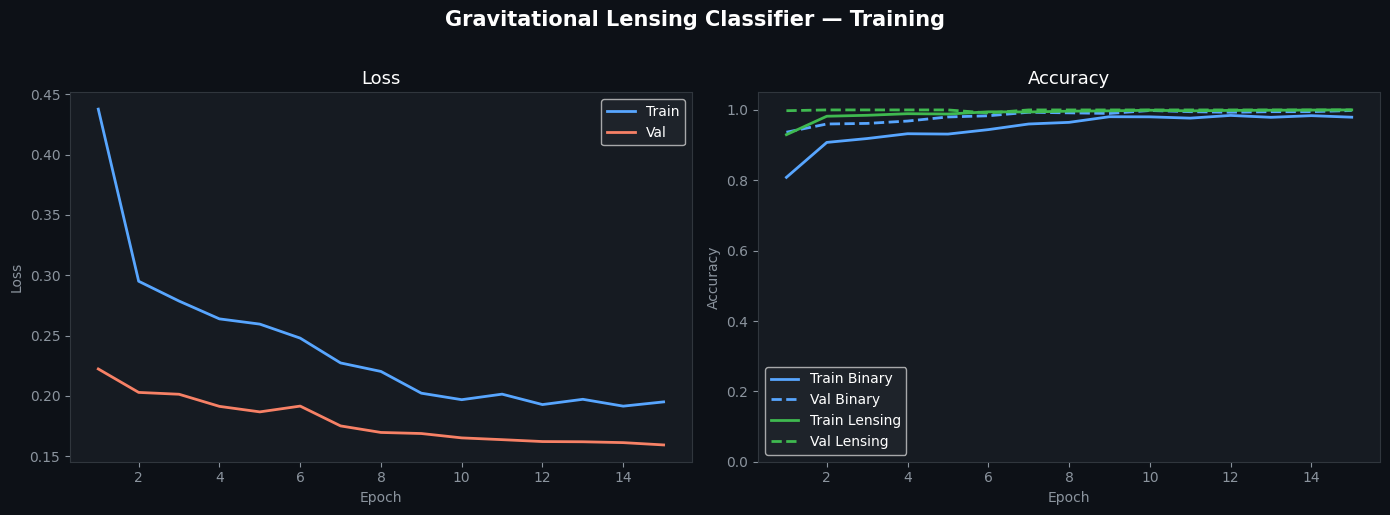

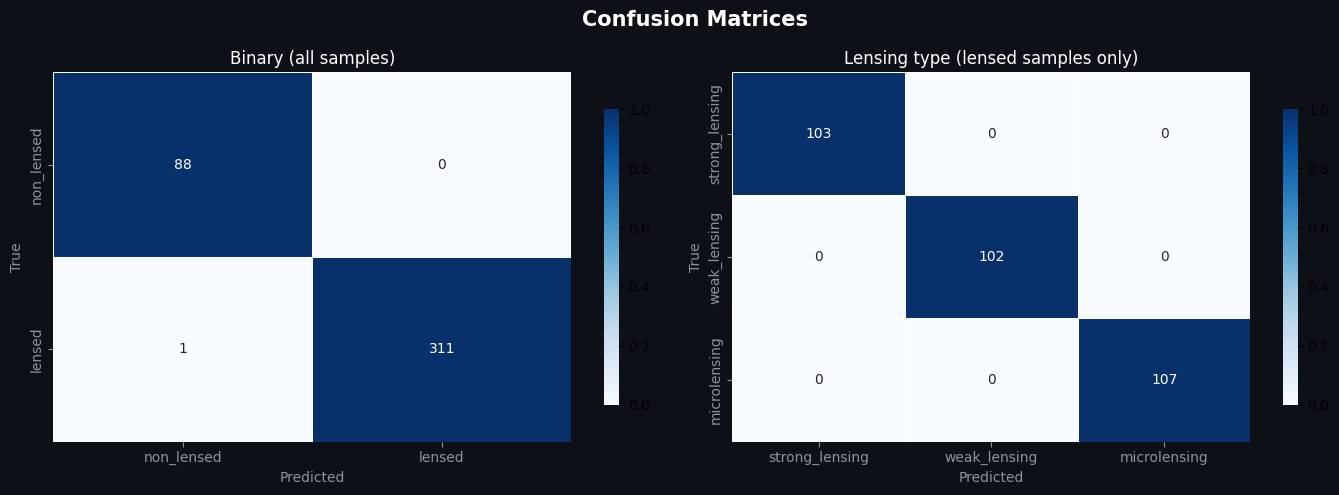


── Binary Classification Report ──────────────────────
              precision    recall  f1-score   support

  non_lensed       0.99      1.00      0.99        88
      lensed       1.00      1.00      1.00       312

    accuracy                           1.00       400
   macro avg       0.99      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


── Lensing Type Report (lensed samples only) ─────────
                precision    recall  f1-score   support

strong_lensing       1.00      1.00      1.00       103
  weak_lensing       1.00      1.00      1.00       102
  microlensing       1.00      1.00      1.00       107

      accuracy                           1.00       312
     macro avg       1.00      1.00      1.00       312
  weighted avg       1.00      1.00      1.00       312



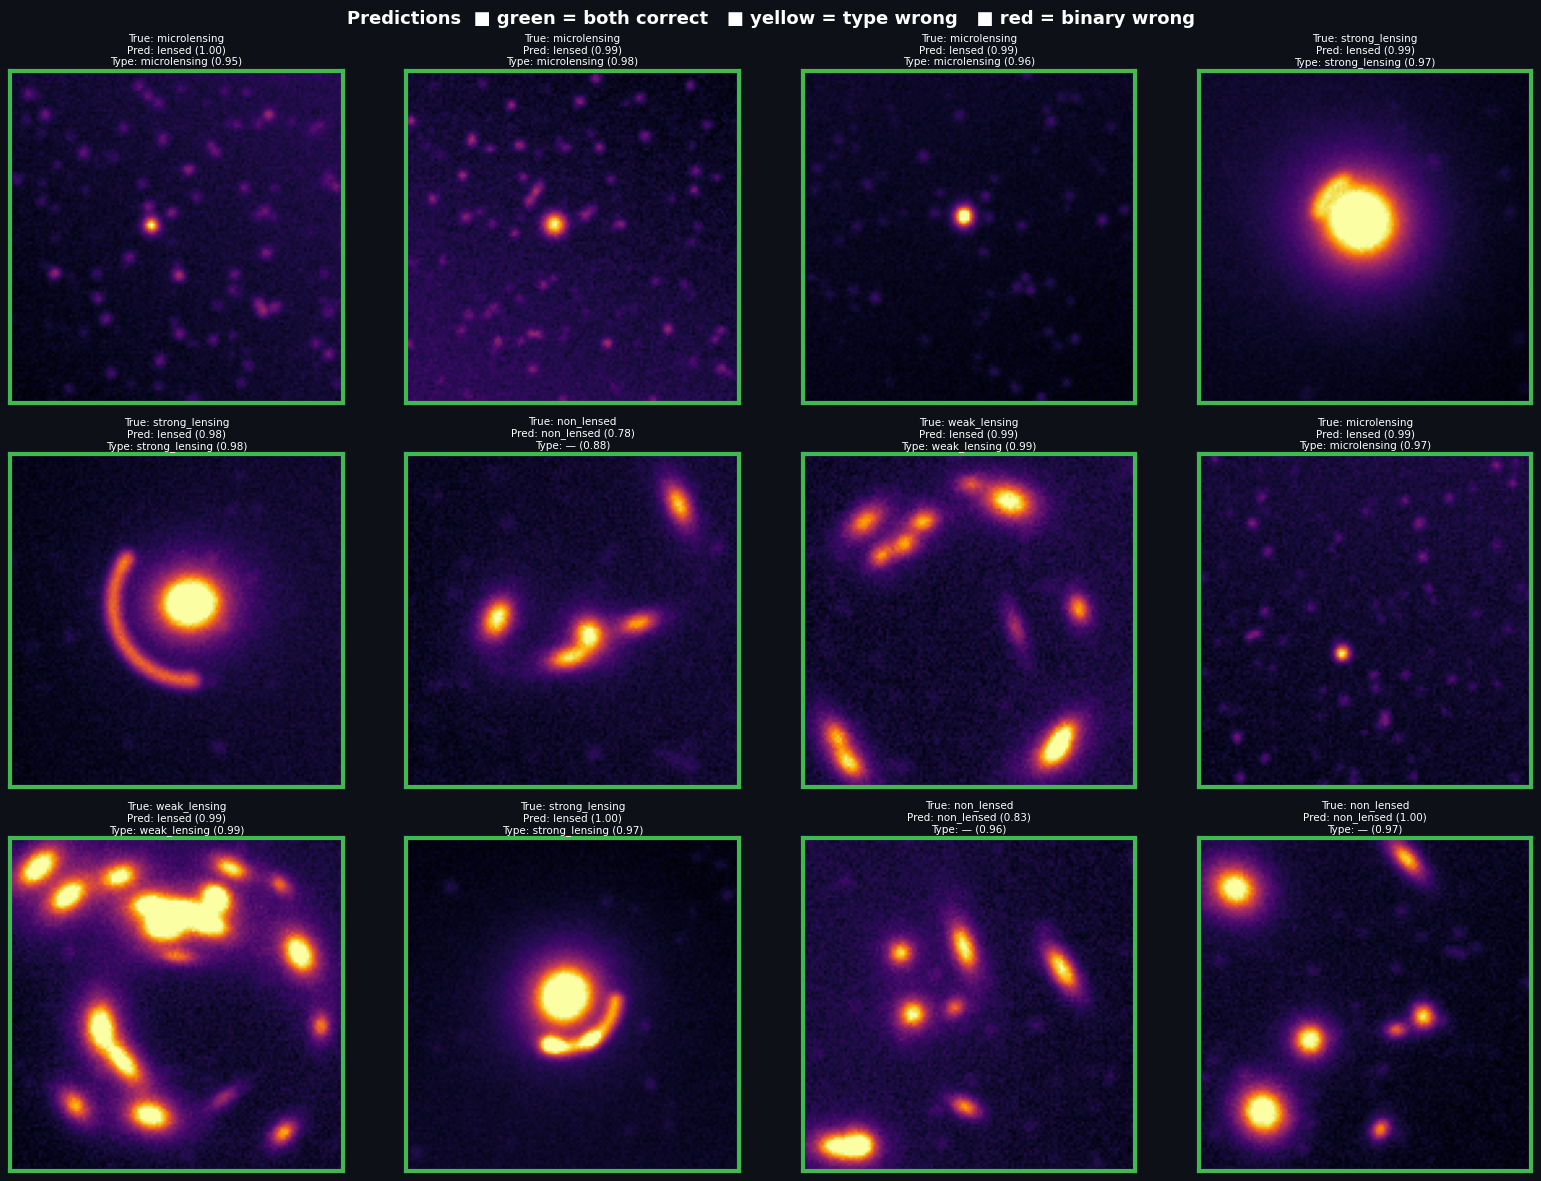


── Single Image Inference ──────────────────────────────
{
  "is_lensed": true,
  "binary_class": "lensed",
  "binary_confidence": 0.9295745491981506,
  "lensing_type": "weak_lensing",
  "lensing_confidence": 0.6664384007453918,
  "all_probabilities": {
    "binary": {
      "non_lensed": 0.07042548060417175,
      "lensed": 0.9295745491981506
    },
    "lensing": {
      "strong_lensing": 0.3052254617214203,
      "weak_lensing": 0.6664384007453918,
      "microlensing": 0.028336206451058388
    }
  }
}


In [ ]:
# ── CELL 11: MAIN — run everything ───────────────────────────
if __name__ == "__main__":
    # Mount check
    checkpoint_path = "/content/drive/MyDrive/best_lensing_modelv3.pt"
    if os.path.exists(checkpoint_path):
        print("Found existing checkpoint — resuming from previous training")
    else:
        print("No checkpoint found — starting fresh")

    # 1. Train
    model, history, test_results, test_loader = train(
        n_samples    = 4000,
        img_size     = 128,
        batch_size   = 32,
        epochs       = 15,
        lr           = 3e-4,
        freeze_epochs= 5,
        backbone     = "mobilenetv3_small_100",
        save_path    = "/content/drive/MyDrive/best_lensing_modelv3.pt",
    )

    bp, lp, bl, ll, lbl_strs = test_results

    print("\n── Final Train/Validation Accuracy Check ─────────────")
    print("Final train binary acc:", history["train_bin_acc"][-1])
    print("Final val binary acc:  ", history["val_bin_acc"][-1])
    print("Final train lens acc:  ", history["train_lens_acc"][-1])
    print("Final val lens acc:    ", history["val_lens_acc"][-1])

    # 2. Curves & reports
    plot_training_curves(history)
    plot_confusion_matrices(bp, lp, bl, ll)
    print_classification_report(bp, lp, bl, ll)

    # 3. Visual sanity check
    visualise_predictions(model, n=12, img_size=128)

    # 4. Single-image inference example
    sample_arr = make_strong_lensing(64)
    result = predict_image(model, sample_arr)
    print("\n── Single Image Inference ──────────────────────────────")
    print(json.dumps(result, indent=2))

In [ ]:
# ── CELL 12: Load pre-trained model (optional) ───────────────

# To reload a saved model without retraining:
#
# model = LensingClassifier(backbone="efficientnet_b3", pretrained=False).to(DEVICE)
# ckpt  = torch.load("best_lensing_model.pt", map_location=DEVICE)
# model.load_state_dict(ckpt["model_state"])
# model.eval()
#
# result = predict_image(model, "/path/to/your/image.png")
# print(result)


In [ ]:
# ── CELL 13: Using Real Data ──────────────────────────────────
#
# 1. Mount Google Drive:
#    from google.colab import drive
#    drive.mount('/content/drive')
#
# 2. Organise data:
#    /content/drive/MyDrive/lensing_data/
#        non_lensed/       (FITS or PNG)
#        strong_lensing/
#        weak_lensing/
#        microlensing/
#
# 3. Create dataset:
#    real_ds = LensingDataset(
#        use_synthetic=False,
#        root_dir="/content/drive/MyDrive/lensing_data"
#    )
#
# Recommended public datasets:
# • CMB-S4 strong lensing sims: https://cmb-s4.org
# • Space Warps: https://spacewarps.org  (citizen science strong lensing)
# • HSC-SSP: https://hsc-release.mtk.nao.ac.jp
# • OGLE microlensing: https://ogle.astrouw.edu.pl
# • KiDS weak lensing: https://kids.strw.leidenuniv.nl